# Official ECG-JEPA Checkpoint Evaluation

This notebook mirrors `eval.ipynb`, but loads the author's official ECG-JEPA multi-block checkpoint from `ecg_jepa/multiblock_epoch100.pth` and evaluates frozen representations on the same local PTB-XL `.npy` downstream data.

Comparison note: this notebook now defaults to `data/ptbxl_500hz_2500_raw`, which is built from original PTB-XL 500 Hz records and saved directly as `(12, 2500)`. You can toggle to normalized or legacy arrays via `PTBXL_DATA_DIR` in the dataset-loading cell.

In [1]:
from __future__ import annotations

import copy
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset

ROOT = Path.cwd()
if not (ROOT / "src" / "data" / "ptbxl_dataset.py").is_file():
    ROOT = ROOT.parent

OFFICIAL_ROOT = ROOT / "ecg_jepa"
CHECKPOINT = OFFICIAL_ROOT / "multiblock_epoch100.pth"

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(OFFICIAL_ROOT))

from src.data.ptbxl_dataset import PTBXLDataset
from ecg_jepa import ecg_jepa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT)
print("official repo:", OFFICIAL_ROOT)
print("checkpoint:", CHECKPOINT, CHECKPOINT.is_file())
print("device:", device)

/home/aimakeradmin/shady/TS-JEPA/.jepa/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: /home/aimakeradmin/shady/TS-JEPA
official repo: /home/aimakeradmin/shady/TS-JEPA/ecg_jepa
checkpoint: /home/aimakeradmin/shady/TS-JEPA/ecg_jepa/multiblock_epoch100.pth True
device: cuda


## Load Official Multi-Block Encoder

The author's checkpoint stores only the encoder state dict under `encoder`, with `epoch=99`. The official model's inference method is `encoder.representation(wave)`, which returns the pooled `(batch, 768)` representation directly.

In [2]:
def build_official_encoder(ckpt_path: Path) -> nn.Module:
    model = ecg_jepa(
        encoder_embed_dim=768,
        encoder_depth=12,
        encoder_num_heads=16,
        predictor_embed_dim=384,
        predictor_depth=6,
        predictor_num_heads=12,
        drop_path_rate=0.1,
        mask_scale=(0.175, 0.225),
        mask_type="block",
        pos_type="sincos",
        c=8,
        p=50,
        t=50,
    )
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.encoder.load_state_dict(ckpt["encoder"], strict=True)
    print("Loaded official checkpoint epoch:", ckpt.get("epoch"))
    encoder = model.encoder
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad_(False)
    return encoder


encoder = build_official_encoder(CHECKPOINT).to(device)
encoder

Loaded official checkpoint epoch: 99


MaskTransformer(
  (encoder_blocks): Encoder_Block(
    (blocks): ModuleList(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=False)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
      )
      (1): Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (drop_path): DropPath(drop_prob=0.009)
        (norm2): LayerNorm((768,), eps

In [3]:
# Smoke test: official encoder expects raw 8-lead, 2500-sample waves.
x = torch.randn(2, 8, 2500, device=device)
with torch.no_grad():
    z = encoder.representation(x)
print("representation shape:", z.shape)

representation shape: torch.Size([2, 768])


## Load PTB-XL Downstream Data

These are the same saved arrays used by `eval.ipynb`.

In [4]:
# Toggle between datasets for A/B comparisons.
PTBXL_DATA_DIR = ROOT / "data/ptbxl_500hz_2500_raw"
# PTBXL_DATA_DIR = ROOT / "data/ptbxl_500hz_2500_norm"
# PTBXL_DATA_DIR = ROOT / "data/ptbxl"  # legacy 12x1000 arrays

trainset = PTBXLDataset(PTBXL_DATA_DIR, split="train", return_labels=True)
valset = PTBXLDataset(PTBXL_DATA_DIR, split="val", return_labels=True)
testset = PTBXLDataset(PTBXL_DATA_DIR, split="test", return_labels=True)

print("PTBXL_DATA_DIR:", PTBXL_DATA_DIR)
print("train/val/test:", len(trainset), len(valset), len(testset))
x0, y0 = trainset[0]
print("sample:", x0.shape, y0)

PTBXL_DATA_DIR: /home/aimakeradmin/shady/TS-JEPA/data/ptbxl_500hz_2500_raw
train/val/test: 17111 2156 2163
sample: torch.Size([12, 2500]) tensor([0., 0., 0., 1., 0.])


In [5]:
# JEPA paper lead subset: I, II, V1-V6 (drop III/aVR/aVL/aVF).
KEEP_LEAD_IDXS = torch.tensor([0, 1, 6, 7, 8, 9, 10, 11], dtype=torch.long)
TARGET_T = 2500


def prepare_signal_for_official_encoder(x: torch.Tensor) -> torch.Tensor:
    if x.shape[-1] != TARGET_T:
        raise ValueError(
            f"Expected input length {TARGET_T} from PTBXL_DATA_DIR, got {x.shape[-1]}"
        )
    idx = KEEP_LEAD_IDXS.to(device=x.device)
    return x.index_select(dim=1, index=idx)


with torch.no_grad():
    xb = torch.stack([trainset[i][0] for i in range(2)]).to(device)
    xb = prepare_signal_for_official_encoder(xb)
    zb = encoder.representation(xb)
print("prepared wave:", xb.shape)
print("features:", zb.shape)

prepared wave: torch.Size([2, 8, 2500])
features: torch.Size([2, 768])


## Feature Extraction and eRank

The official encoder already returns pooled features, so eRank here is computed over the downstream representation matrix `(num_samples, 768)`.

In [6]:
@torch.no_grad()
def extract_features(dataset, batch_size: int = 256, max_samples: int | None = None):
    if max_samples is not None:
        dataset = Subset(dataset, range(min(max_samples, len(dataset))))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    feats, labels = [], []
    encoder.eval()
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        x = prepare_signal_for_official_encoder(x)
        z = encoder.representation(x).float().cpu()
        feats.append(z)
        labels.append(y.float())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)


def effective_rank(Z: torch.Tensor, eps: float = 1e-8) -> float:
    Z = Z.float()
    Z = Z - Z.mean(dim=0, keepdim=True)
    cov = (Z.T @ Z) / max(Z.size(0) - 1, 1)
    eigvals = torch.linalg.eigvalsh(cov).clamp(min=0)
    total = eigvals.sum()
    if total < eps:
        return 1.0
    p = eigvals / total
    return float((-(p * (p + eps).log()).sum()).exp().item())

In [7]:
# Cache features once for the frozen linear probe.
train_features, train_labels = extract_features(trainset, batch_size=256)
val_features, val_labels = extract_features(valset, batch_size=256)
test_features, test_labels = extract_features(testset, batch_size=256)

print("train features:", train_features.shape)
print("val features:", val_features.shape, "eRank", effective_rank(val_features))
print("test features:", test_features.shape, "eRank", effective_rank(test_features))

train features: torch.Size([17111, 768])
val features: torch.Size([2156, 768]) eRank 30.079492568969727
test features: torch.Size([2163, 768]) eRank 30.289003372192383


## Frozen Linear Probe

This mirrors the quick probe from `eval.ipynb`: train a linear head on a fixed subset of training features and evaluate macro AUROC/AUPRC on the PTB-XL test set.

In [8]:
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score

torch.manual_seed(0)
np.random.seed(0)

NUM_CLASSES = train_labels.shape[1]
LINEAR_TRAIN_SAMPLES = train_features.shape[0]

probe_train = TensorDataset(train_features[:LINEAR_TRAIN_SAMPLES], train_labels[:LINEAR_TRAIN_SAMPLES])
probe_test = TensorDataset(test_features, test_labels)
probe_train_loader = DataLoader(probe_train, batch_size=512, shuffle=True)
probe_test_loader = DataLoader(probe_test, batch_size=512, shuffle=False)

pos_counts = train_labels[:LINEAR_TRAIN_SAMPLES].sum(dim=0)
neg_counts = LINEAR_TRAIN_SAMPLES - pos_counts
pos_weight = (neg_counts / pos_counts.clamp_min(1.0)).to(device)
print("pos_weight:", pos_weight)

linear_head = nn.Linear(train_features.shape[1], NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(linear_head.parameters(), lr=3e-3)


def train_probe_epoch() -> float:
    linear_head.train()
    total = 0.0
    for x, y in probe_train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(linear_head(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / max(len(probe_train_loader), 1)


def evaluate_probe() -> dict[str, float]:
    linear_head.eval()
    probs, labels = [], []
    with torch.no_grad():
        for x, y in probe_test_loader:
            logits = linear_head(x.to(device))
            probs.append(torch.sigmoid(logits).cpu())
            labels.append(y.cpu())
    probs_np = torch.cat(probs).numpy()
    labels_np = torch.cat(labels).numpy()
    preds_np = (probs_np >= 0.5).astype(int)
    print(classification_report(labels_np, preds_np, zero_division=0))
    return {
        "macro_auroc": roc_auc_score(labels_np, probs_np, average="macro"),
        "macro_auprc": average_precision_score(labels_np, probs_np, average="macro"),
    }

pos_weight: tensor([3.3740, 7.0674, 2.8986, 1.2494, 3.0808], device='cuda:0')


In [9]:
probe_losses = []
for epoch in range(10):
    loss = train_probe_epoch()
    probe_losses.append(loss)
    print(f"epoch {epoch + 1:02d} | loss {loss:.4f}")

probe_metrics = evaluate_probe()
print(probe_metrics)

epoch 01 | loss 0.7286
epoch 02 | loss 0.6001
epoch 03 | loss 0.5736
epoch 04 | loss 0.5578
epoch 05 | loss 0.5491
epoch 06 | loss 0.5405
epoch 07 | loss 0.5364
epoch 08 | loss 0.5327
epoch 09 | loss 0.5293
epoch 10 | loss 0.5250
              precision    recall  f1-score   support

           0       0.60      0.77      0.67       498
           1       0.39      0.82      0.53       263
           2       0.60      0.72      0.66       553
           3       0.78      0.93      0.85       964
           4       0.66      0.84      0.74       523

   micro avg       0.64      0.83      0.72      2801
   macro avg       0.61      0.82      0.69      2801
weighted avg       0.65      0.83      0.73      2801
 samples avg       0.69      0.83      0.73      2801

{'macro_auroc': 0.9031340417035428, 'macro_auprc': 0.7667401240230053}


## Optional Few-Shot Fine-Tuning

This mirrors the few-shot fine-tuning style in `eval.ipynb`. It updates the official encoder, so it is slower than the frozen probe.

In [23]:
def make_multilabel_fewshot_subset(dataset, n_per_class: int = 128, seed: int = 0) -> Subset:
    rng = np.random.default_rng(seed)
    labels = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        labels.append(y.numpy())
    labels = np.asarray(labels)
    selected: set[int] = set()
    for c in range(labels.shape[1]):
        idx = np.where(labels[:, c] == 1)[0]
        rng.shuffle(idx)
        selected.update(idx[:n_per_class].tolist())
    return Subset(dataset, sorted(selected))


class OfficialFineTuneClassifier(nn.Module):
    def __init__(self, encoder: nn.Module, num_classes: int):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(768, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = prepare_signal_for_official_encoder(x)
        z = self.encoder.representation(x)
        return self.head(z)


fewshot_trainset = make_multilabel_fewshot_subset(trainset, n_per_class=128)
print("few-shot train size:", len(fewshot_trainset))

ft_train_loader = DataLoader(fewshot_trainset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
ft_val_loader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
ft_test_loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

few-shot train size: 634


In [11]:
ft_encoder = build_official_encoder(CHECKPOINT).to(device)
ft_model = OfficialFineTuneClassifier(ft_encoder, NUM_CLASSES).to(device)

fewshot_features, fewshot_labels = extract_features(fewshot_trainset, batch_size=128)
fewshot_pos = fewshot_labels.sum(dim=0)
fewshot_neg = fewshot_labels.shape[0] - fewshot_pos
fewshot_pos_weight = (fewshot_neg / fewshot_pos.clamp_min(1.0)).to(device)
print("few-shot pos_weight:", fewshot_pos_weight)

ft_loss = nn.BCEWithLogitsLoss(pos_weight=fewshot_pos_weight)
ft_optimizer = torch.optim.AdamW(
    [
        {"params": ft_model.encoder.parameters(), "lr": 1e-5},
        {"params": ft_model.head.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4,
)
ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ft_optimizer, T_max=15)


def run_ft_epoch(loader: DataLoader, train: bool) -> dict[str, float]:
    ft_model.train(train)
    total_loss = 0.0
    count = 0
    probs, labels = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.set_grad_enabled(train):
            logits = ft_model(x)
            loss = ft_loss(logits, y)
            if train:
                ft_optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
                ft_optimizer.step()
        total_loss += loss.item() * x.shape[0]
        count += x.shape[0]
        probs.append(torch.sigmoid(logits).detach().cpu())
        labels.append(y.detach().cpu())
    probs_np = torch.cat(probs).numpy()
    labels_np = torch.cat(labels).numpy()
    return {
        "loss": total_loss / max(count, 1),
        "auroc": roc_auc_score(labels_np, probs_np, average="macro"),
        "auprc": average_precision_score(labels_np, probs_np, average="macro"),
    }

Loaded official checkpoint epoch: 99
few-shot pos_weight: tensor([1.4669, 2.2513, 1.8304, 3.4028, 1.5360], device='cuda:0')


In [ ]:
best_val_auprc = -float("inf")
best_state = None

for epoch in range(1, 16):
    train_metrics = run_ft_epoch(ft_train_loader, train=True)
    val_metrics = run_ft_epoch(ft_val_loader, train=False)
    ft_scheduler.step()
    print(
        f"Epoch {epoch:02d} | train loss {train_metrics['loss']:.4f} | "
        f"train AUPRC {train_metrics['auprc']:.4f} | val loss {val_metrics['loss']:.4f} | "
        f"val AUPRC {val_metrics['auprc']:.4f}"
    )
    if val_metrics["auprc"] > best_val_auprc:
        best_val_auprc = val_metrics["auprc"]
        best_state = {k: v.detach().cpu().clone() for k, v in ft_model.state_dict().items()}

if best_state is not None:
    ft_model.load_state_dict(best_state)

test_metrics = run_ft_epoch(ft_test_loader, train=False)
print("few-shot fine-tune test:", test_metrics)

Epoch 01 | train loss 0.8757 | train AUPRC 0.5198 | val loss 0.8022 | val AUPRC 0.5196
Epoch 02 | train loss 0.7920 | train AUPRC 0.6457 | val loss 0.7161 | val AUPRC 0.5541
Epoch 03 | train loss 0.7358 | train AUPRC 0.6903 | val loss 0.6898 | val AUPRC 0.5743
Epoch 04 | train loss 0.7014 | train AUPRC 0.7030 | val loss 0.6468 | val AUPRC 0.5887


## T-SNE: pretrained vs fine-tuned encoder

Same setup as `eval.ipynb`: single-label samples from PTB-XL test+val, pooled `(768,)` embeddings from `encoder.representation`, then side-by-side T-SNE colored by the single positive superclass. Run this **after** the few-shot fine-tuning loop so `ft_model` holds the best checkpoint.

Single-label samples: 3294 / 4396
Embeddings shape: (3294, 768)


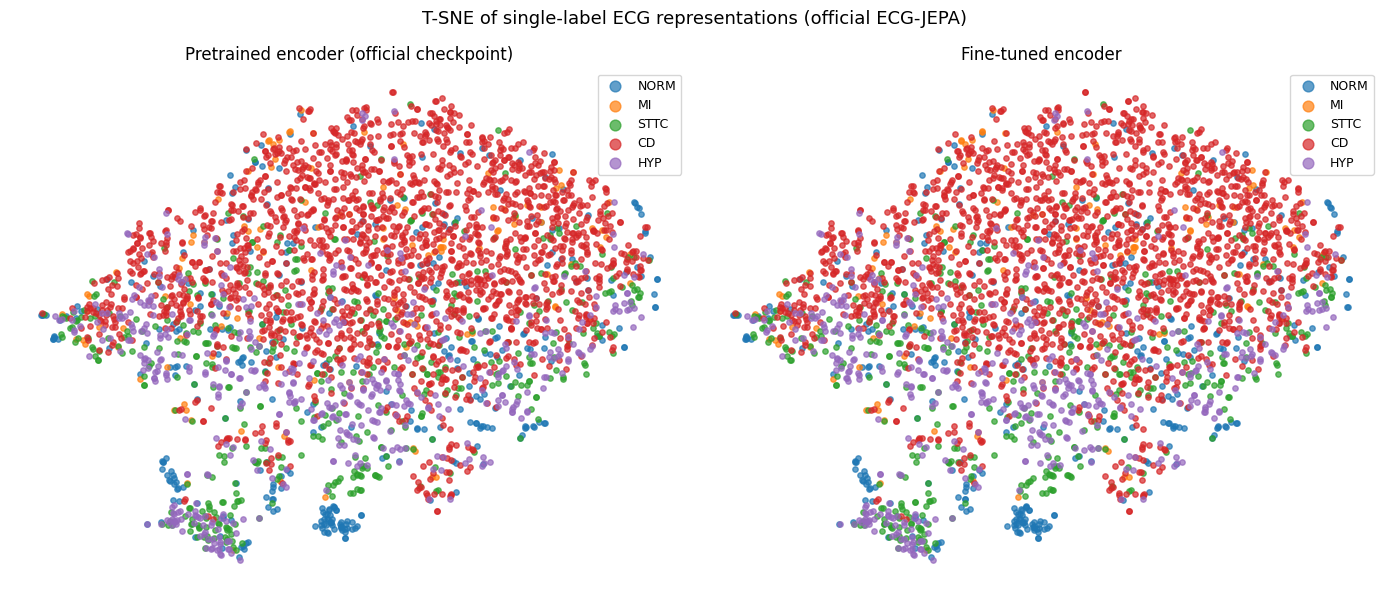

In [13]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# --- Filter to single-label samples from test + val sets (same as eval.ipynb) ---
single_label_signals, single_label_classes = [], []
for dataset in [testset, valset]:
    for sig, lbl in dataset:
        if lbl.sum().item() == 1:
            single_label_signals.append(sig)
            single_label_classes.append(lbl.argmax().item())

signals_tensor = torch.stack(single_label_signals)  # (N, 12, 1000)
classes_array = np.array(single_label_classes)  # (N,)
print(f"Single-label samples: {len(signals_tensor)} / {len(testset) + len(valset)}")


@torch.no_grad()
def get_official_embeddings(enc: nn.Module, signals: torch.Tensor, batch_size: int = 64) -> np.ndarray:
    """Pooled official representation (bs, 768) per sample."""
    enc.eval()
    all_embs = []
    for i in range(0, len(signals), batch_size):
        batch = signals[i : i + batch_size].to(device)
        batch = prepare_signal_for_official_encoder(batch)
        z = enc.representation(batch).float().cpu()
        all_embs.append(z)
    return torch.cat(all_embs, dim=0).numpy()


embs_pretrained = get_official_embeddings(encoder, signals_tensor)
embs_finetuned = get_official_embeddings(ft_model.encoder, signals_tensor)
print("Embeddings shape:", embs_pretrained.shape)

tsne_kwargs = dict(n_components=2, perplexity=30, random_state=42)
try:
    tsne = TSNE(**tsne_kwargs, n_jobs=-1)
except TypeError:
    tsne = TSNE(**tsne_kwargs)

proj_pre = tsne.fit_transform(embs_pretrained)
proj_ft = tsne.fit_transform(embs_finetuned)

CLASS_NAMES = ["NORM", "MI", "STTC", "CD", "HYP"]
colors = plt.cm.tab10(np.arange(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, proj, title in [
    (axes[0], proj_pre, "Pretrained encoder (official checkpoint)"),
    (axes[1], proj_ft, "Fine-tuned encoder"),
]:
    for cls_idx, name in enumerate(CLASS_NAMES):
        mask = classes_array == cls_idx
        ax.scatter(
            proj[mask, 0],
            proj[mask, 1],
            c=[colors[cls_idx]],
            label=name,
            s=15,
            alpha=0.7,
        )
    ax.set_title(title, fontsize=12)
    ax.legend(loc="best", markerscale=2, fontsize=9)
    ax.axis("off")

plt.suptitle("T-SNE of single-label ECG representations (official ECG-JEPA)", fontsize=13)
plt.tight_layout()
plt.show()